# Ice Area Extent Ensemble Notebook
The CmCt Ice Area Extent tool compares user uploaded ice sheet model to satellite ice area extent data. The CmCT interpolates modeled ice sheets to the same grid as the satellite data, and then calculates the direct difference between the two. This notebook is designed to preprocess and analyze ice area extent for an ensemble of models preprocessed. 

If you have a preprocessed statistics file from the ice_area_extent_ensemble notebook, you can load it here. If not, you can run the ice_area_extent_ensemble notebook to preprocess the data.


## ISMIP Icemask Annual Dataset Description
For comparison to the user's model, the tool uses the ISMIP Icemask dataset, which provides a mask of the ice sheet area for each year from 1973 to 2021. The dataset is available at [ISMIP Icemask](https://www.ismip.org/ismip-icemask/). The tool uses the annual mean ice area extent for each year in the dataset.

## Input Data Requirements 
The input ice sheet model data should be in NetCDF format with the following variables:
- `time`: Time variable in years.
- `x`: Gridded X variable.
- `y`: Gridded Y variable.
- `ice_mask`: Ice mask variable.

### Data Range
The tool supports times from 1973 to 2021. The user can select a specific time range within this period for analysis.

In [1]:
## Import modules
import os, sys
import numpy as np
import geopandas as gpd
import cftime
import gc
import shapely
import json
from ipywidgets import interact, FloatSlider
import ipywidgets as widgets
import matplotlib.pyplot as plt
import glob
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.colors as pc
from ipywidgets import interact, IntSlider, Dropdown, VBox, HBox
import ipywidgets as widgets
import psutil
import time 
import numba
numba.set_num_threads(2)


# Add the directory containing 'cmct' to the Python path
# Navigate two levels up to reach main CmCt dir
cmct_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, os.pardir))

# Initialising Logger
import logging

logging.basicConfig(
    level=logging.WARNING, format="%(asctime)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)

# Import utilities for this comparison
sys.path.insert(0, cmct_dir)

# Import specific ice_area_extent functions directly to avoid package init issues
import importlib.util
spec = importlib.util.spec_from_file_location("cmct.ice_area_extent", 
                                              os.path.join(cmct_dir, "cmct", "ice_area_extent.py"))
ice_area_extent_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ice_area_extent_module)

from cmct.time_utils import *
# Import the logging configuration function
configure_ice_area_extent_logging = ice_area_extent_module.configure_ice_area_extent_logging
from cmct.ice_area_extent_modules.interpolation import *
from cmct.ice_area_extent_modules.residual_calculation import *

# Get other functions from the module
load_basins = ice_area_extent_module.load_basins
load_observations_ice_area_extent = ice_area_extent_module.load_observations_ice_area_extent

# Force initial garbage collection
gc.collect()


91

In [2]:
# Reload modules to pick up any changes to imports
import importlib
import sys

# Clear module from cache to force reload
if 'cmct.ice_area_extent' in sys.modules:
    del sys.modules['cmct.ice_area_extent']
if 'cmct.ice_area_extent_modules.residual_calculation' in sys.modules:
    del sys.modules['cmct.ice_area_extent_modules.residual_calculation']

import cmct.ice_area_extent
import cmct.ice_area_extent_modules.residual_calculation
from cmct.ice_area_extent_modules.plotting_utils import *
from cmct.ice_area_extent import calculate_basin_statistics, format_basin_stats
from cmct.ice_area_extent import calculate_basin_statistics

importlib.reload(cmct.ice_area_extent)
importlib.reload(cmct.ice_area_extent_modules.residual_calculation)

# Re-import to ensure functions are available
from cmct.ice_area_extent import *

# Memory monitoring utility
def get_memory_usage():
    """Get current memory usage in MB"""
    import psutil
    process = psutil.Process()
    return process.memory_info().rss / 1024 / 1024

def log_memory_usage(stage=""):
    """Log current memory usage"""
    try:
        mem_usage = get_memory_usage()
        logging.info(f"Memory usage {stage}: {mem_usage:.1f} MB")
    except ImportError:
        logging.warning("psutil not available for memory monitoring")
    except Exception as e:
        logging.error(f"Error checking memory: {e}")

# Check initial memory usage
log_memory_usage("at start")

# CONFIGURATION

In [3]:
# Observation Dataset
# Ice sheet
loc = "GIS"  # 'GIS' or 'AIS'

# Set the observation data dir path
obs_filename = cmct_dir + "/data/ice_area_extent/observed_icemask_ismip_annual.nc"

# To use aggregation functions for basin
basin_aggregation = True  # IMPORTANT

basin_filename = (
    cmct_dir + "/bin/ice_area_extent/GRE_Basins_IMBIE2_v1.3/GRE_Basins_IMBIE2_v1.3.shp"
)

# Set the preprocessed model stats dir path 
model_dir = cmct_dir + "/test/ice_area_extent/ensemble/ENSEMBLE_OUTPUT.npy"

# Change this code to add model names
model_names = []
for i in range(1, 151):
    model_names.append("sftgif_B" + str(i).zfill(3) + "_hist") # this line specifically
    logging.info(model_names[-1])



# Set time range for comparison
start_year = 2007
end_year = 2015

# List of basins (ex ["NW", "NE"]) to compare if all -> "all", if none -> False
# If you do not know which basins are in the model, you can put "auto"
# NOTE: Align this list with the basins in the model.
basin_list = ["NW"]

# Output filetype and filename
filetype = "netcdf"  # netcdf or json or None
filename = "ice_area_extent_comparison"

# Optional Configurations
interpolation_method = "slinear"  # 'nearest', 'linear', 'cubic'
accuracy_calculation_method = "mean"  # 'mean', 'RMS',

colors = {
    "CW": "blue",
    "NE": "red",
    "SE": "green",
    "SW": "orange",
    "NO": "purple",
    "NW": "brown",
}

plt.figure(figsize=(12, 8))

MAX_CPU = 80
MAX_MEM = 80

# LOGGING CONFIGURATION
# Options: "ALL", "ERROR", "WARNING", "INFO"
log_level = "ERROR"  # Set to "ERROR" to show only errors, "ALL" to show all logs


<Figure size 1200x800 with 0 Axes>

In [4]:
ice_area_extent_logger = configure_ice_area_extent_logging(log_level)

# Check if observation file exist
if not os.path.exists(obs_filename):
    raise FileNotFoundError(f"Observation file not found: {obs_filename}")


if basin_aggregation and not os.path.exists(basin_filename):
    raise FileNotFoundError(f"Basin shapefile not found: {basin_filename}")
    # Load basin shapes

print(basin_filename)
basins, basin_list = load_basins(basin_filename, basin_list)

print(obs_filename)
observations = load_observations_ice_area_extent(obs_filename, basins)
observations.ds["time"] = standardising_time_var(observations.time)

observations_stats = calculate_observations_statistics(observations, basins)



/Users/aditya_pachpande/Documents/GitHub/CmCt/bin/ice_area_extent/GRE_Basins_IMBIE2_v1.3/GRE_Basins_IMBIE2_v1.3.shp
/Users/aditya_pachpande/Documents/GitHub/CmCt/data/ice_area_extent/observed_icemask_ismip_annual.nc


In [5]:
print(observations_stats)
np.save("observations_stats.npy", observations_stats)

{'NW': {np.float64(1973.0): {'count': 270870, 'mean': np.float64(0.9933462177428287), 'std': np.float64(0.06185225411429242), 'min': np.float64(0.0), 'max': np.float64(1.0), 'rms': np.float64(0.9952700184588111), 'rss': np.float64(268313.6399), 'sum': np.float64(269067.69), 'winsorized_mean': 1.0, 'outlier_weighted_mean': np.float64(0.9999792034698074)}, np.float64(1974.0): {'count': 270870, 'mean': np.float64(0.993339350980175), 'std': np.float64(0.061893163400958004), 'min': np.float64(0.0), 'max': np.float64(1.0), 'rms': np.float64(0.9952657081812338), 'rss': np.float64(268311.3159), 'sum': np.float64(269065.83), 'winsorized_mean': 1.0, 'outlier_weighted_mean': np.float64(0.9999791842488035)}, np.float64(1975.0): {'count': 270870, 'mean': np.float64(0.9933344777937758), 'std': np.float64(0.06189719576123881), 'min': np.float64(0.0), 'max': np.float64(1.0), 'rms': np.float64(0.995261095199113), 'rss': np.float64(268308.82869999995), 'sum': np.float64(269064.51000000007), 'winsorized_

In [6]:
def process_single_model_with_mask(
    file, observations, basin_mask, basin_names, x_coords, y_coords, start_year, end_year
):
    """
    Process a single model file using pre-computed basin mask.

    Parameters
    ----------
    file : str
        Path to the model file
    observations : GSFCice_area_extent
        GSFC ice_area_extent data object
    basin_mask : np.ndarray
        Pre-computed basin mask
    basin_names : list
        List of basin names
    x_coords : np.ndarray
        X coordinates
    y_coords : np.ndarray
        Y coordinates
    start_year : int
        Start year for analysis
    end_year : int
        End year for analysis

    Returns
    -------
    dict
        Basin statistics for the model
    """
    logging.info(f"Processing: {file}")

    try:
        model_res = load_model_ice_area_extent(file)

        # Validate model data
        if model_res is None or model_res.ds is None:
            raise ValueError(f"Failed to load model data from {file}")

        model_res.ds["time"] = standardising_time_var(model_res.time)

        # Handle Time Range with validation
        try:
            checking_ice_area_extent_daterange(
                observations.time.values, model_res.time.values, start_year, end_year
            )
        except Exception as e:
            logging.warning(f"Warning: Time range validation failed: {e}")

        # Interpolation with error handling
        try:
            interpolater = Interpolater(model_res, observations)
            model_res.ds = interpolater.interpolate()
            logging.info(f"Resampled data shape: {model_res.ds.dims}")
        except Exception as e:
            logging.warning(f"Warning: Interpolation failed: {e}")
            # Continue with original resolution if interpolation fails

        years = np.arange(start_year, end_year + 1)

        # Create residuals dataset using pre-computed basin mask
        try:
            residuals_dataset = create_ice_area_extent_dataset_with_precomputed_mask(
                observations, model_res, years, basin_mask, basin_names, x_coords, y_coords
            )

            # Validate dataset
            if residuals_dataset is None:
                raise ValueError("Failed to create residuals dataset")

        except Exception as e:
            logging.error(f"Error creating residuals dataset: {e}")
            # Return empty stats if dataset creation fails
            return {
                year: {"NW": {"count": 0, "mean": np.nan, "std": np.nan}}
                for year in years
            }

        # Load residuals with error handling
        try:
            residuals = load_residuals(residuals_dataset)
            if residuals is None:
                raise ValueError("Failed to load residuals")
        except Exception as e:
            logging.error(f"Error loading residuals: {e}")
            return {
                year: {"NW": {"count": 0, "mean": np.nan, "std": np.nan}}
                for year in years
            }

        # Calculate basin statistics with error handling
        try:
            basin_stats = calculate_basin_statistics(residuals)
            logging.info(format_basin_stats(basin_stats))
        except Exception as e:
            logging.error(f"Error calculating basin statistics: {e}")
            basin_stats = {
                year: {"NW": {"count": 0, "mean": np.nan, "std": np.nan}}
                for year in years
            }

        # Memory cleanup
        del model_res, interpolater, residuals_dataset, residuals
        gc.collect()

        return basin_stats

    except Exception as e:
        logging.error(f"Error processing model file {file}: {e}")
        # Return fallback statistics
        years = np.arange(start_year, end_year + 1)
        return {
            year: {"NW": {"count": 0, "mean": np.nan, "std": np.nan}} for year in years
        }


# Ensemble Plotting and Analysis

### IF YOU HAVE A PRE-PROCESSED STATS ARRAY FILE

In [7]:
# OPTIONAL 
# If you have a model file pre-processed that has stats, you can load it here

basin_stats_array = np.load(model_dir, allow_pickle=True)

if isinstance(basin_stats_array, np.ndarray):
    basin_stats_array = basin_stats_array.tolist()
else:
    basin_stats_array = basin_stats_array


In [8]:
# Reload the plotting module to ensure latest changes are available
import importlib
import cmct.ice_area_extent_modules.plotting_utils
importlib.reload(cmct.ice_area_extent_modules.plotting_utils)

# Import ensemble plotting utilities
from cmct.ice_area_extent_modules.plotting_utils import (
    create_ensemble_time_series_plot,
    create_interactive_ensemble_plot,
    create_ensemble_statistics_summary,
)

## PLOTTING CONFIGURATIONS

In [9]:
# Create interactive ensemble plot without GSFC line
logging.info(f"Models: {model_names}")
logging.info(f"Basins: {basin_list}")

# Convert NumPy array to Python list if needed
if isinstance(basin_stats_array, np.ndarray):
    basin_stats_list = basin_stats_array.tolist()
    logging.info("Converted NumPy array to Python list")
else:
    basin_stats_list = basin_stats_array
    logging.info("Using existing list")

# Create the interactive plot without GSFC
ensemble_plot_widget = create_interactive_ensemble_plot(
    basin_stats_list, 
    model_names, 
    basin_list=basin_list, 
)

# Display the widget
ensemble_plot_widget


# Add units to the plots

In [10]:
# Reload the plotting module to get the new advanced plotting function
import importlib
import cmct.ice_area_extent_modules.plotting_utils
importlib.reload(cmct.ice_area_extent_modules.plotting_utils)

# Import the new advanced plotting function
from cmct.ice_area_extent_modules.plotting_utils import create_advanced_ensemble_comparison_plot

In [11]:
# Create the advanced interactive comparison widget
advanced_comparison_widget = create_advanced_ensemble_comparison_plot(
    basin_stats_array,
    model_names,
    basin_list=basin_list,
    start_year=start_year,
    end_year=end_year
)

# Display the widget
advanced_comparison_widget

In [31]:
create_interactive_ensemble_box_whiskers_plot(basin_stats_array, model_names, basin_list)

interactive(children=(Dropdown(description='Statistic:', options=(('Mean', 'mean'), ('Standard Deviation', 'st…

In [19]:
# Reload the fixed module
import importlib
import cmct.ice_area_extent_modules.ensemble_reweighting
importlib.reload(cmct.ice_area_extent_modules.ensemble_reweighting)

from cmct.ice_area_extent_modules.ensemble_reweighting import EnsembleReweighter

# Create new reweighter instance with fixed code
reweighter = EnsembleReweighter(
    observations_stats=observations_stats, 
    scoring_method='combined'
)

# Test with first model
print("Testing fixed scoring method...")
test_score = reweighter._calculate_model_score(basin_stats_array[0], ["NW"], [2007, 2008])
print(f"Test score: {test_score}")

if not np.isinf(test_score):
    print("Success! Recalculating all ensemble scores...")
    
    # Recalculate all scores
    ensemble_scores = reweighter.calculate_ensemble_scores(
        basin_stats_array=basin_stats_array,
        basin_list=basin_list,
        years=years_range
    )
    
    print(f"New scores - Range: {np.min(ensemble_scores):.4f} to {np.max(ensemble_scores):.4f}")
    print(f"Mean: {np.mean(ensemble_scores):.4f}, Std: {np.std(ensemble_scores):.4f}")
    
    # Show some example scores
    print(f"First 10 scores: {ensemble_scores[:10]}")
else:
    print("Still getting infinite score - there may be another issue.")

Testing fixed scoring method...
Test score: 1.1905484602200542
Success! Recalculating all ensemble scores...
New scores - Range: 1.1778 to 1.2057
Mean: 1.1985, Std: 0.0052
First 10 scores: [1.19194031 1.19984603 1.19531372 1.19858065 1.19868255 1.19464247
 1.20308874 1.20244761 1.19228457 1.20160352]


In [25]:
# Reload the module to pick up fixes
import importlib
import cmct.ice_area_extent_modules.ensemble_reweighting
importlib.reload(cmct.ice_area_extent_modules.ensemble_reweighting)

# Import ensemble reweighting functionality
from cmct.ice_area_extent_modules.ensemble_reweighting import (
    EnsembleReweighter,
    create_performance_comparison_plot,
    calculate_ensemble_uncertainty
)

# Initialize the reweighter with observation statistics
print("Initializing ensemble reweighter...")
reweighter = EnsembleReweighter(
    observations_stats=observations_stats, 
    scoring_method='combined'  # Options: 'rmse', 'mae', 'correlation', 'combined'
)

# Calculate performance scores for all ensemble members
print(f"Calculating scores for {len(basin_stats_array)} ensemble members...")
years_range = list(range(start_year, end_year + 1))

ensemble_scores = reweighter.calculate_ensemble_scores(
    basin_stats_array=basin_stats_array,
    basin_list=basin_list,
    years=years_range
)

print(f"Raw scores calculated. Range: {np.min(ensemble_scores):.4f} to {np.max(ensemble_scores):.4f}")
print(f"Mean score: {np.mean(ensemble_scores):.4f}, Std: {np.std(ensemble_scores):.4f}")

Initializing ensemble reweighter...
Calculating scores for 150 ensemble members...
Raw scores calculated. Range: 1.1778 to 1.2057
Mean score: 1.1985, Std: 0.0052


In [26]:
# Normalize scores (convert to higher=better scale)
print("Normalizing scores with working ensemble scores...")
normalized_scores = reweighter.normalize_scores(method='minmax')  # Options: 'minmax', 'zscore', 'rank', 'inverse'

# Calculate KDE-based weights
print("Calculating KDE weights...")
kde_weights = reweighter.calculate_kde_weights(adaptive=True)

# Display weight statistics
print(f"\nWeight Statistics:")
print(f"Min weight: {np.min(kde_weights):.6f}")
print(f"Max weight: {np.max(kde_weights):.6f}")
print(f"Mean weight: {np.mean(kde_weights):.6f}")
print(f"Std weight: {np.std(kde_weights):.6f}")
print(f"Weight ratio (max/min): {np.max(kde_weights)/np.min(kde_weights):.2f}")
print(f"Effective sample size: {1/np.sum(kde_weights**2):.2f}")

# Identify top performing models
weight_summary = reweighter.get_weight_summary()
print(f"\nTop 10 performing models:")
print(weight_summary.head(10)[['model_index', 'raw_score', 'weight', 'weight_percentile']])

Normalizing scores with working ensemble scores...
Calculating KDE weights...

Weight Statistics:
Min weight: 0.000000
Max weight: 0.009864
Mean weight: 0.006667
Std weight: 0.002636
Weight ratio (max/min): 6725004613.07
Effective sample size: 129.73

Top 10 performing models:
     model_index  raw_score    weight  weight_percentile
36            36   1.199714  0.009864         100.000000
107          107   1.199745  0.009862          99.333333
99            99   1.199787  0.009858          98.666667
1              1   1.199846  0.009848          98.000000
55            55   1.199902  0.009834          97.333333
79            79   1.199998  0.009802          96.666667
80            80   1.200004  0.009800          96.000000
136          136   1.200018  0.009794          95.333333
11            11   1.199297  0.009787          94.666667
40            40   1.199290  0.009784          94.000000


In [27]:
# Calculate reweighted ensemble statistics
print("Calculating reweighted ensemble statistics...")
reweighted_stats = reweighter.get_reweighted_statistics(
    basin_stats_array=basin_stats_array,
    basin_list=basin_list,
    years=years_range
)

# Calculate ensemble uncertainty with and without weighting
print("Calculating uncertainty metrics...")

# Unweighted (equal weights)
equal_weights = np.ones(len(basin_stats_array)) / len(basin_stats_array)
unweighted_uncertainty = calculate_ensemble_uncertainty(
    basin_stats_array=basin_stats_array,
    weights=equal_weights,
    basin_list=basin_list,
    years=years_range
)

# Weighted 
weighted_uncertainty = calculate_ensemble_uncertainty(
    basin_stats_array=basin_stats_array,
    weights=kde_weights,
    basin_list=basin_list,
    years=years_range
)

print("Reweighting complete!")

# Compare unweighted vs weighted statistics for a sample year/basin
sample_year = years_range[len(years_range)//2]  # Middle year
sample_basin = basin_list[0]

print(f"\nComparison for {sample_year}, {sample_basin}:")
print(f"Unweighted - Mean: {unweighted_uncertainty[sample_year][sample_basin]['ensemble_mean']:.4f}, "
      f"Std: {unweighted_uncertainty[sample_year][sample_basin]['ensemble_std']:.4f}")
print(f"Weighted   - Mean: {weighted_uncertainty[sample_year][sample_basin]['ensemble_mean']:.4f}, "
      f"Std: {weighted_uncertainty[sample_year][sample_basin]['ensemble_std']:.4f}")
print(f"Effective N: {weighted_uncertainty[sample_year][sample_basin]['effective_n']:.2f} (vs {len(basin_stats_array)} total models)")

Calculating reweighted ensemble statistics...
Calculating uncertainty metrics...
Reweighting complete!

Comparison for 2011, NW:
Unweighted - Mean: 0.0017, Std: 0.0001
Weighted   - Mean: 0.0017, Std: 0.0001
Effective N: 129.73 (vs 150 total models)


Creating performance visualization...


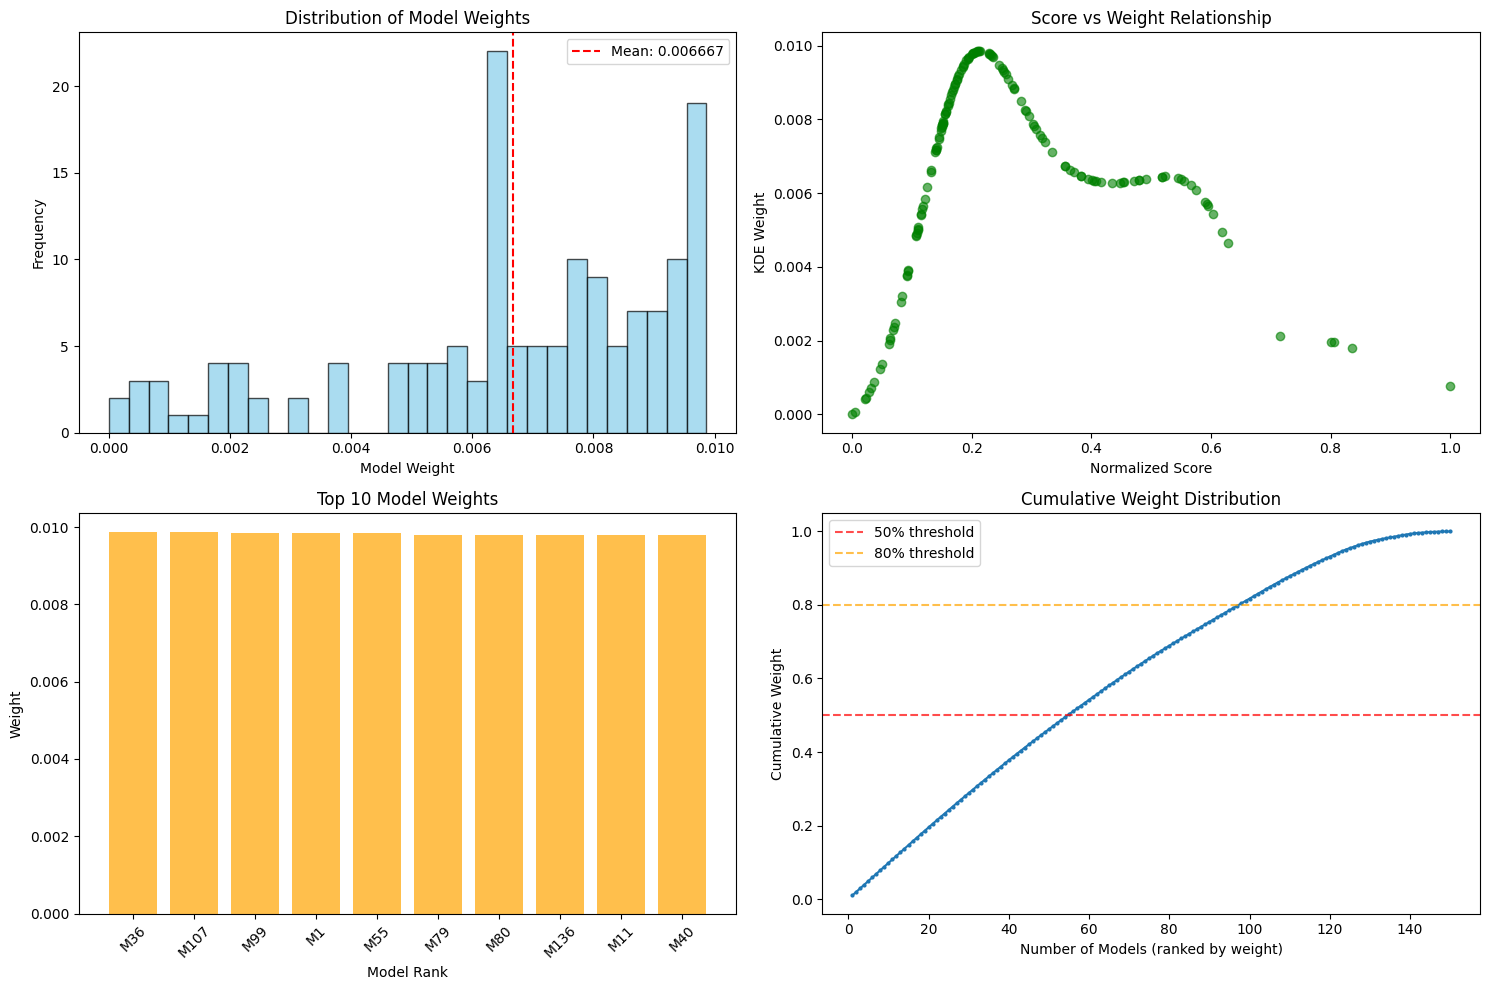


Weight concentration analysis:
Top 55 models contribute 50% of total weight
Top 98 models contribute 80% of total weight
Weight concentration ratio (50%): 55/150 = 36.7%


In [28]:
# Create performance comparison plot
print("Creating performance visualization...")
performance_plot = create_performance_comparison_plot(
    reweighter=reweighter,
    model_names=model_names,
    title="Ensemble Member Performance and Weighting"
)

# Display the plot
performance_plot.show()

# Show weight distribution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Weight histogram
axes[0,0].hist(kde_weights, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].set_xlabel('Model Weight')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Distribution of Model Weights')
axes[0,0].axvline(np.mean(kde_weights), color='red', linestyle='--', label=f'Mean: {np.mean(kde_weights):.6f}')
axes[0,0].legend()

# Score vs Weight scatter
axes[0,1].scatter(normalized_scores, kde_weights, alpha=0.6, color='green')
axes[0,1].set_xlabel('Normalized Score')
axes[0,1].set_ylabel('KDE Weight')
axes[0,1].set_title('Score vs Weight Relationship')

# Top models bar chart
top_models = weight_summary.head(10)
axes[1,0].bar(range(len(top_models)), top_models['weight'], color='orange', alpha=0.7)
axes[1,0].set_xlabel('Model Rank')
axes[1,0].set_ylabel('Weight')
axes[1,0].set_title('Top 10 Model Weights')
axes[1,0].set_xticks(range(len(top_models)))
axes[1,0].set_xticklabels([f"M{idx}" for idx in top_models['model_index']], rotation=45)

# Cumulative weight distribution
sorted_weights = np.sort(kde_weights)[::-1]
cumulative_weights = np.cumsum(sorted_weights)
axes[1,1].plot(range(1, len(cumulative_weights)+1), cumulative_weights, marker='o', markersize=2)
axes[1,1].set_xlabel('Number of Models (ranked by weight)')
axes[1,1].set_ylabel('Cumulative Weight')
axes[1,1].set_title('Cumulative Weight Distribution')
axes[1,1].axhline(0.5, color='red', linestyle='--', alpha=0.7, label='50% threshold')
axes[1,1].axhline(0.8, color='orange', linestyle='--', alpha=0.7, label='80% threshold')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# Calculate how many models contribute to 50% and 80% of total weight
cum_weight_50 = np.where(cumulative_weights >= 0.5)[0][0] + 1
cum_weight_80 = np.where(cumulative_weights >= 0.8)[0][0] + 1

print(f"\nWeight concentration analysis:")
print(f"Top {cum_weight_50} models contribute 50% of total weight")
print(f"Top {cum_weight_80} models contribute 80% of total weight")
print(f"Weight concentration ratio (50%): {cum_weight_50}/{len(basin_stats_array)} = {cum_weight_50/len(basin_stats_array)*100:.1f}%")

In [29]:
# Create interactive comparison widget for weighted vs unweighted ensemble
def create_weighted_comparison_widget(weighted_stats, unweighted_stats, basin_list, years_range):
    """Create interactive widget to compare weighted vs unweighted ensemble statistics"""
    
    def update_comparison_plot(basin_selection, metric_selection):
        fig = make_subplots(
            rows=1, cols=2,
            subplot_titles=('Ensemble Mean Comparison', 'Ensemble Uncertainty Comparison'),
            shared_xaxes=True
        )
        
        # Extract data for selected basin
        years = years_range
        unweighted_means = [unweighted_stats[year][basin_selection]['ensemble_mean'] for year in years]
        weighted_means = [weighted_stats[year][basin_selection]['ensemble_mean'] for year in years]
        unweighted_stds = [unweighted_stats[year][basin_selection]['ensemble_std'] for year in years]
        weighted_stds = [weighted_stats[year][basin_selection]['ensemble_std'] for year in years]
        
        # Plot means
        fig.add_trace(
            go.Scatter(x=years, y=unweighted_means, mode='lines+markers', 
                      name='Unweighted', line=dict(color='blue')),
            row=1, col=1
        )
        fig.add_trace(
            go.Scatter(x=years, y=weighted_means, mode='lines+markers', 
                      name='Weighted', line=dict(color='red')),
            row=1, col=1
        )
        
        # Plot uncertainties
        if metric_selection == 'Standard Deviation':
            fig.add_trace(
                go.Scatter(x=years, y=unweighted_stds, mode='lines+markers', 
                          name='Unweighted Std', line=dict(color='lightblue')),
                row=1, col=2
            )
            fig.add_trace(
                go.Scatter(x=years, y=weighted_stds, mode='lines+markers', 
                          name='Weighted Std', line=dict(color='pink')),
                row=1, col=2
            )
        else:  # Effective sample size
            unweighted_n = [unweighted_stats[year][basin_selection]['effective_n'] for year in years]
            weighted_n = [weighted_stats[year][basin_selection]['effective_n'] for year in years]
            
            fig.add_trace(
                go.Scatter(x=years, y=unweighted_n, mode='lines+markers', 
                          name='Unweighted N_eff', line=dict(color='lightblue')),
                row=1, col=2
            )
            fig.add_trace(
                go.Scatter(x=years, y=weighted_n, mode='lines+markers', 
                          name='Weighted N_eff', line=dict(color='pink')),
                row=1, col=2
            )
        
        fig.update_xaxes(title_text="Year")
        fig.update_yaxes(title_text="Ice Area Extent Residual", row=1, col=1)
        fig.update_yaxes(title_text=metric_selection, row=1, col=2)
        
        fig.update_layout(
            title=f"Weighted vs Unweighted Ensemble Comparison - {basin_selection}",
            height=500
        )
        
        return fig
    
    # Create widgets
    basin_dropdown = widgets.Dropdown(
        options=basin_list,
        value=basin_list[0],
        description='Basin:'
    )
    
    metric_dropdown = widgets.Dropdown(
        options=['Standard Deviation', 'Effective Sample Size'],
        value='Standard Deviation',
        description='Metric:'
    )
    
    # Create interactive plot
    interactive_plot = widgets.interactive(
        update_comparison_plot,
        basin_selection=basin_dropdown,
        metric_selection=metric_dropdown
    )
    
    return interactive_plot

# Create and display the weighted comparison widget
weighted_comparison_widget = create_weighted_comparison_widget(
    weighted_uncertainty, unweighted_uncertainty, basin_list, years_range
)

print("Interactive weighted vs unweighted comparison:")
display(weighted_comparison_widget)

Interactive weighted vs unweighted comparison:


interactive(children=(Dropdown(description='Basin:', options=('NW',), value='NW'), Dropdown(description='Metri…

In [30]:
# Save reweighted results
print("Saving reweighted ensemble results...")

# Save weights and scores
results_dict = {
    'model_names': model_names,
    'ensemble_scores': ensemble_scores,
    'normalized_scores': normalized_scores,
    'kde_weights': kde_weights,
    'weight_summary': weight_summary.to_dict(),
    'reweighted_statistics': reweighted_stats,
    'weighted_uncertainty': weighted_uncertainty,
    'unweighted_uncertainty': unweighted_uncertainty,
    'configuration': {
        'scoring_method': reweighter.scoring_method,
        'basin_list': basin_list,
        'years_range': years_range,
        'start_year': start_year,
        'end_year': end_year
    }
}

# Save to numpy file
np.save('ensemble_reweighted_results.npy', results_dict)
print("Results saved to 'ensemble_reweighted_results.npy'")

# Print final summary
print("\n" + "="*60)
print("ENSEMBLE REWEIGHTING SUMMARY")
print("="*60)
print(f"Total ensemble members: {len(basin_stats_array)}")
print(f"Scoring method: {reweighter.scoring_method}")
print(f"Analysis period: {start_year}-{end_year}")
print(f"Basins analyzed: {', '.join(basin_list)}")
print(f"\nWeight statistics:")
print(f"  - Min weight: {np.min(kde_weights):.6f}")
print(f"  - Max weight: {np.max(kde_weights):.6f}")
print(f"  - Weight ratio (max/min): {np.max(kde_weights)/np.min(kde_weights):.1f}")
print(f"  - Effective sample size: {1/np.sum(kde_weights**2):.2f}")
print(f"\nPerformance concentration:")
print(f"  - Top {cum_weight_50} models contribute 50% of weight")
print(f"  - Top {cum_weight_80} models contribute 80% of weight")

# Identify best and worst performing models
best_model_idx = weight_summary.iloc[0]['model_index']
worst_model_idx = weight_summary.iloc[-1]['model_index']
print(f"\nBest performing model: {model_names[int(best_model_idx)]} (weight: {kde_weights[int(best_model_idx)]:.6f})")
print(f"Worst performing model: {model_names[int(worst_model_idx)]} (weight: {kde_weights[int(worst_model_idx)]:.6f})")

print("\nReweighting complete! Use the weighted statistics for improved ensemble projections.")

Saving reweighted ensemble results...
Results saved to 'ensemble_reweighted_results.npy'

ENSEMBLE REWEIGHTING SUMMARY
Total ensemble members: 150
Scoring method: combined
Analysis period: 2007-2015
Basins analyzed: NW

Weight statistics:
  - Min weight: 0.000000
  - Max weight: 0.009864
  - Weight ratio (max/min): 6725004613.1
  - Effective sample size: 129.73

Performance concentration:
  - Top 55 models contribute 50% of weight
  - Top 98 models contribute 80% of weight

Best performing model: sftgif_B037_hist (weight: 0.009864)
Worst performing model: sftgif_B031_hist (weight: 0.000000)

Reweighting complete! Use the weighted statistics for improved ensemble projections.
